In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import glob
import csv
import ast
import json
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
from decimal import Decimal

In [2]:
# define functions

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def loglog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def xlog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

In [3]:
#  fetch assets
x2name = csv2dict('../data/assets/xgroup2/xgroup2name.csv')
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
xgroup2ds_ab = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv')

## Create dict 'loo' with all Leave One Out results

In [4]:
folder_path = '../LOO/'
files_pattern = '*.pkl.gz'
files = glob.glob(folder_path + files_pattern)

loo = {}

# Iterate over each file
for file_path in files:
    # Extract the fold number from the file name
    fold_number = file_path.split('__')[1].split('.')[0]
    
    # Read the pickle file and populate loo dictionary
    loo[fold_number] = pd.read_pickle(file_path)

## Collect the network sizes in cpds_subiter[1] from each dict in loo

In [5]:
# create xgroup2networkSize dict

xgroup2ns = {}
for xgroup in loo:
    if xgroup not in ['spontaneous', 'fold_independent']:  # ignore non-fold leave-one-out reults
        xgroup2ns[xgroup] = len(loo[xgroup].cpds_subiter[1])

In [6]:
len(xgroup2ns)

396

In [7]:
# save dict as csv
# dict2csv(xgroup2ns, '../data/assets/xgroup2/xgroup2networkSize.csv')

# create x2rulesNum from rn2rules

In [8]:
def numRulesWith(xgroup, rn2rules):
    numRules = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                numRules += 1
    return numRules

In [9]:
x2rulesNum = {}
for xgroup in xgroup2ns.keys():
    x2rulesNum[xgroup] = numRulesWith(xgroup, rn2rules)

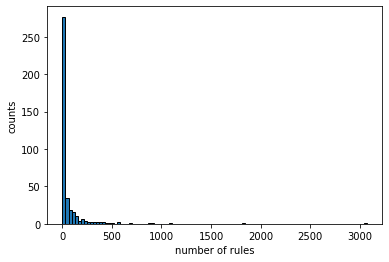

In [10]:
histogram(x2rulesNum, bins=100, x_axis = 'number of rules')

In [11]:
# dict2csv(x2rulesNum, '../data/assets/xgroup2/xgroup2rulesNum.csv')

# scatterplot: network size vs. #rules

network size vs. #rules: corr = -0.5967755739391494, p_value = 1.4385173409919075e-39


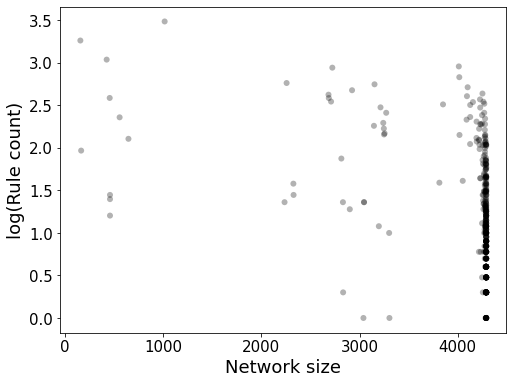

In [12]:
corr, p = spearman(xgroup2ns, x2rulesNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

valid_keys, data1, data2 = todata(xgroup2ns, x2rulesNum)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color='k', alpha = 0.3, label='Data Points', zorder=2)

# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
# ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('Network size', fontsize=18)
ax.set_ylabel('log(Rule count)', fontsize=18)
plt.tick_params(labelsize=15)

# plt.savefig('scatter_networkSize2numRulesLog.svg', dpi=300, bbox_inches = 'tight')
plt.show()

# divide xgroups based on two 'network size' thresholds: 1500 and 3600

In [13]:
# network size < 1500 => first10

xgroup2sub1500 = {}
xgroup2sup1500 = {}
for xgroup in xgroup2ns:
    if xgroup2ns[xgroup] < 1500:
        xgroup2sub1500[xgroup] = xgroup2ns[xgroup]
    else:
        xgroup2sup1500[xgroup] = xgroup2ns[xgroup]

In [14]:
# network size < 3600 => group1
# network size >= 3600 => group2

groupOne2ns = {}
groupTwo2ns = {}
for xgroup in xgroup2ns:
    if xgroup2ns[xgroup] < 3600:
        groupOne2ns[xgroup] = xgroup2ns[xgroup]
    else:
        groupTwo2ns[xgroup] = xgroup2ns[xgroup]

In [15]:
first10 = list(xgroup2sub1500.keys())
group1 = list(groupOne2ns.keys())
group2 = list(groupTwo2ns.keys())

# The first division is CoA; second division is Oxygen

### first10 vs. others

In [16]:
cpds = list(loo['2002'].cpds_folditer.keys())

In [19]:
cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')

In [20]:
divider_cpds_first10 = []  # list of cpds that don't exist in any first10 LOO networks, but always exist others
for cpd in cpds:
    divide = [True, True]
    for x in first10:
        if loo[x].cpds_subiter[1].get(cpd, 'N/A') != 'N/A':  # check if absent
            divide[0] = False
            break
    for x in (set(group2) | set(group1)) - set(first10):
        if loo[x].cpds_subiter[1].get(cpd, 'N/A') == 'N/A':  # check if present
            divide[1] = False
            break

    if False not in divide:
        print(f"{cpd} {cpd2name[cpd]} divides first10 vs. others")
        divider_cpds_first10.append(cpd)

C20843 N5-Phenyl-L-glutamine divides first10 vs. others
C01920 Geranoyl-CoA divides first10 vs. others
C06473 2-Keto-D-gluconic acid divides first10 vs. others
C00879 D-Galactarate divides first10 vs. others
C09810 Cyclohexa-1,4-diene-1-carbonyl-CoA divides first10 vs. others
C00333 D-Galacturonate divides first10 vs. others
C03561 (R)-3-Hydroxybutanoyl-CoA divides first10 vs. others
C06440 2-Dehydro-D-glucono-1,5-lactone divides first10 vs. others
C21643 3-Dehydro-scyllo-inosose divides first10 vs. others
C05360 Diimine divides first10 vs. others
C05402 Melibiose divides first10 vs. others
C03345 2-Methylbut-2-enoyl-CoA divides first10 vs. others
C11354 2-Hydroxy-cis-hex-2,4-dienoate divides first10 vs. others
C00024 Acetyl-CoA divides first10 vs. others
C03383 D-Galactono-1,4-lactone divides first10 vs. others
C01998 Acrylonitrile divides first10 vs. others
C00877 Crotonoyl-CoA divides first10 vs. others
C00894 Propenoyl-CoA divides first10 vs. others
C00261 Benzaldehyde divides firs

C04462 N-Succinyl-2-L-amino-6-oxoheptanedioate divides first10 vs. others
C00827 Lactoyl-CoA divides first10 vs. others
Z00007 CoB divides first10 vs. others
C02331 Vinylacetyl-CoA divides first10 vs. others
C01402 Anilide divides first10 vs. others
C00349 2-Methyl-3-oxopropanoate divides first10 vs. others
C16272 3-Hydroxy-5-oxohexanoate divides first10 vs. others
C02977 GDP-6-deoxy-D-talose divides first10 vs. others
C20483 (6R)-6beta-Hydroxy-1,4,5,6-tetrahydronicotinamide-adenine dinucleotide phosphate divides first10 vs. others
C02780 2,5-Didehydro-D-gluconate divides first10 vs. others
C00313 Oxalyl-CoA divides first10 vs. others
C07350 Phlorisovalerophenone divides first10 vs. others
C03943 (2R,4S)-2,4-Diaminopentanoate divides first10 vs. others
C18169 Diacylglyceryl-N,N,N-trimethylhomoserine divides first10 vs. others
C07118 Benzoylacetyl-CoA divides first10 vs. others
C06002 (S)-Methylmalonate semialdehyde divides first10 vs. others
C04015 N-Acetyl-4-O-acetylneuraminate divide

In [21]:
len(divider_cpds_first10)

316

In [22]:
'C00010' in divider_cpds_first10  # CoA

True

In [23]:
for c in divider_cpds_first10:
    if c.startswith('Z'):
        print(c, cpd2name[c])

Z00037 Pantetheine
Z00051 Coenzyme A
Z00038 Phosphopantetheine
Z00007 CoB


In [24]:
for cpd in divider_cpds_first10:
    if int(cpd[-5:]) < 100:
        print(cpd, cpd2name[cpd])

C00024 Acetyl-CoA
Z00037 Pantetheine
C00091 Succinyl-CoA
C00010 CoA
Z00051 Coenzyme A
C00040 Acyl-CoA
C00083 Malonyl-CoA
Z00038 Phosphopantetheine
Z00007 CoB


In [25]:
# not ATP or NDPH?

In [26]:
cpd = 'C00002'
print(cpd2name[cpd])
print('--------------')
for x in first10:
    print(f"X{x}: {loo[x].cpds_subiter[1].get(cpd, 'N/A')}")
    
# you can get ATP without Rossmann, HUP, or alpha/beta-Hammerhead/Barrel-sandwich hybrid?

ATP
--------------
X2005: 20
X4952: N/A
X325: 20
X2003: 20
X2002: N/A
X602: N/A
X218: N/A
X206: N/A
X4953: N/A
X2007: N/A


In [27]:
cpd = 'C00004'
print(cpd2name[cpd])
print('--------------')
for x in first10:
    print(f"X{x}: {loo[x].cpds_subiter[1].get(cpd, 'N/A')}")
    
# you can get NADH without Rossmann?

NADH
--------------
X2005: N/A
X4952: N/A
X325: N/A
X2003: 22
X2002: N/A
X602: N/A
X218: N/A
X206: N/A
X4953: N/A
X2007: N/A


### group1 vs. group2

In [35]:
divider_cpds_g1g2 = []  # list of cpds that don't exist in any group1 LOO networks, but always exist in group2 LOO
for cpd in cpds:
    divide = [True, True]
    for x in group1:
        if loo[x].cpds_subiter[1].get(cpd, 'N/A') != 'N/A':  # check if absent
            divide[0] = False
            break
    for x in group2:
        if loo[x].cpds_subiter[1].get(cpd, 'N/A') == 'N/A':  # check if present
            divide[1] = False
            break

    if False not in divide:
        print(f"{cpd} {cpd2name[cpd]} divides group1 vs. group2")
        divider_cpds_g1g2.append(cpd)

C21124 IPA imine divides group1 vs. group2
C03666 2-Carboxy-cis,cis-muconate divides group1 vs. group2
C11631 9-Riburonosylhypoxanthine divides group1 vs. group2
C15603 Hydroquinone divides group1 vs. group2
C04106 2-(Hydroxymethyl)-4-oxobutanoate divides group1 vs. group2
C02298 N-Acetylindoxyl divides group1 vs. group2
C02779 2-Dehydro-D-glucose divides group1 vs. group2
C11145 Methanesulfonic acid divides group1 vs. group2
C21803 8-Demethyl-8-formylriboflavin 5'-phosphate divides group1 vs. group2
C00472 p-Benzoquinone divides group1 vs. group2
C17756 2-Descarboxy-cyclo-dopa divides group1 vs. group2
C03824 2-Aminomuconate semialdehyde divides group1 vs. group2
C05856 Thiamine aldehyde divides group1 vs. group2
C15883 2,3-Dimethyl-5-phytylquinol divides group1 vs. group2
C02892 Thiamine acetic acid divides group1 vs. group2
C01133 N-Acetyl-D-glucosaminate divides group1 vs. group2
C12622 cis-3-(3-Carboxyethenyl)-3,5-cyclohexadiene-1,2-diol divides group1 vs. group2
C20526 10,11-Epox

In [36]:
len(divider_cpds_g1g2)

118

In [37]:
'C00007' in divider_cpds_g1g2

True

In [38]:
'C00027' in divider_cpds_g1g2

True

# scatterplot: network size vs. #rules (with colors)

In [39]:
group1minus10ns = {}
for x, ns in groupOne2ns.items():
    if x not in first10:
        group1minus10ns[x] = ns

network size vs. #rules: corr = -0.5967755739391494, p_value = 1.4385173409919075e-39


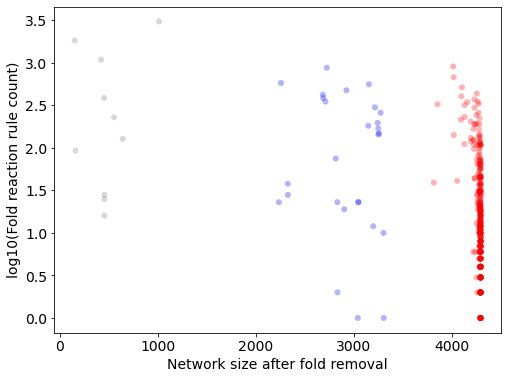

In [40]:
keys, data1, data2 = todata(group1minus10ns, x2rulesNum)
keys, data3, data4 = todata(groupTwo2ns, x2rulesNum)
keys, data5, data6 = todata(xgroup2sub1500, x2rulesNum)

corr, p = spearman(xgroup2ns, x2rulesNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color='b', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data3, np.log10(data4), marker='o', edgecolor='none', color='r', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data5, np.log10(data6), marker='o', edgecolor='none', color='gray', alpha = 0.3, label='Data Points', zorder=2)

# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
# ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('Network size after fold removal', fontsize=14)
ax.set_ylabel('log10(Fold reaction rule count)', fontsize=14)
plt.tick_params(labelsize=14)

# plt.savefig('scatter_networkSize2numRulesLog.svg', dpi=300, bbox_inches = 'tight')
plt.show()

# Boxplot: Phyletic Disribution Scores of Group1 vs. Group2

In [ ]:
keys, data1, data2 = todata(xgroup2ds_ab, groupOne2ns)
keys, data3, data4 = todata(xgroup2ds_ab, groupTwo2ns)
keys, data5, data6 = todata(xgroup2ds_ab, xgroup2sub1500)

group1ds = np.array(data1)
group2ds = np.array(data3)
first10ds = np.array(data5)
group1minus10ds = np.array(list(set(data1) - set(data5)))

fig, ax = plt.subplots(figsize=(1.7, 4))

# Use seaborn boxplot
boxplot = sns.boxplot(data=[group1ds, group2ds], width=0.5, ax=ax, medianprops=dict(color="black", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0))

# data points
colors = ['blue', 'red']
sns.stripplot(data=[group1minus10ds, group2ds], palette=colors, size=3, jitter=True, ax=ax, alpha=0.8)
colors = ['gray', 'red']
sns.stripplot(data=[first10ds, group2ds], palette=colors, size=3, jitter=True, ax=ax, alpha=0.8)

###
# U-test
statistic, p_value = mannwhitneyu(group1ds, group2ds)
p_value = '%.1E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
###

plt.tick_params(labelsize=10)
plt.ylabel('Microbial distribution score', fontsize=11)
ax.set_xticklabels(['Group I', 'Group II'], fontsize=11)

# plt.savefig('boxplot_ds_g1g2_first10.svg', dpi=300, bbox_inches = 'tight')
plt.show()

# Color based on redox ETU

In [43]:
x_FAD = {'1001', '146', '179', '187', '207', '217', '244', '262', '278', '296', '313', '3249', '3281', '3294', '3321', '3322', '3323', '3579', '3740', '378', '3892', '4019', '4033', '4052', '4294', '604', '6058', '6094', '629', '633', '66', '7', '7514', '7564', '7586', '842', '875', '881', '914', '920'}
x_NAD_no_Z32 = {'129', '146', '147', '148', '159', '179', '187', '213', '217', '221', '222', '236', '237', '239', '244', '2486', '262', '266', '270', '276', '3115', '313', '3249', '3294', '3321', '3322', '3323', '3579', '3654', '3687', '3692', '3697', '3699', '378', '3892', '4004', '4011', '4029', '4033', '4049', '4052', '4294', '4335', '503', '5100', '581', '604', '6058', '6094', '6096', '6166', '640', '66', '7', '7501', '7514', '7522', '7524', '7531', '7556', '7584', '7586', '842', '920'}

In [48]:
x_FAD_ns = {x:xgroup2ns[x] for x in x_FAD}
x_NAD_ns = {x:xgroup2ns[x] for x in x_NAD_no_Z32}

others_ns = {}
for x, ns in xgroup2ns.items():
    if x not in x_NAD_ns and x not in x_FAD_ns:
        others_ns[x] = ns

print(len(x_FAD_ns), len(x_NAD_ns), len(others_ns))

40 64 319


network size vs. #rules: corr = -0.5967755739391494, p_value = 1.4385173409919075e-39


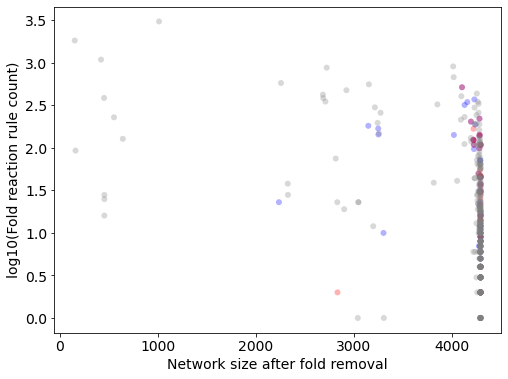

In [50]:
keys, data1, data2 = todata(x_NAD_ns, x2rulesNum)
keys, data3, data4 = todata(x_FAD_ns, x2rulesNum)
keys, data5, data6 = todata(others_ns, x2rulesNum)

corr, p = spearman(xgroup2ns, x2rulesNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color='b', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data3, np.log10(data4), marker='o', edgecolor='none', color='r', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data5, np.log10(data6), marker='o', edgecolor='none', color='gray', alpha = 0.3, label='Data Points', zorder=2)

# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
# ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('Network size after fold removal', fontsize=14)
ax.set_ylabel('log10(Fold reaction rule count)', fontsize=14)
plt.tick_params(labelsize=14)

# plt.savefig('scatter_networkSize2numRulesLog_redox.svg', dpi=300, bbox_inches = 'tight')
plt.show()